<a href="https://colab.research.google.com/github/sasurasa/Lin/blob/main/APRI_Log_Box.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Number of observations at each time point:
              Time Jaundice clearance  n
           Pre-HPE          Clearance 64
           Pre-HPE       No clearance 40
Immediate\npost-op          Clearance 62
Immediate\npost-op       No clearance 38
             Day 7          Clearance 61
             Day 7       No clearance 38
           Month 1          Clearance 60
           Month 1       No clearance 30
           Month 4          Clearance 58
           Month 4       No clearance 27
           Month 5          Clearance 59
           Month 5       No clearance 25
           Month 6          Clearance 61
           Month 6       No clearance 23
            Year 2          Clearance 62
            Year 2       No clearance 16


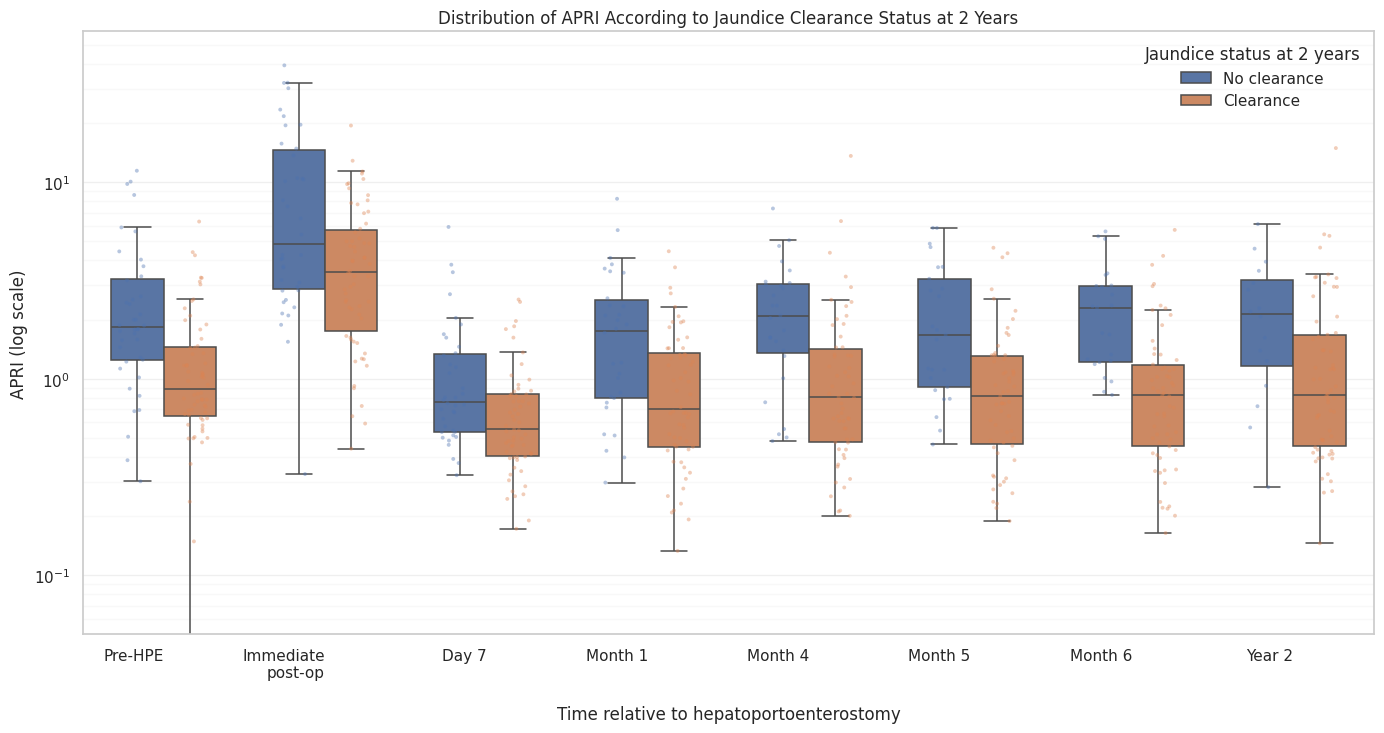

In [4]:
# ============================================================
# Box plots of APRI over time by 2-year jaundice clearance
# Logarithmic y-axis
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Read the dataset
# ------------------------------------------------------------

file_path = "/content/apri.xlsx"
sheet_name = "cleanup (2)"   # Change if your sheet name differs

df = pd.read_excel(
    file_path,
    sheet_name=sheet_name
)

# ------------------------------------------------------------
# 2. Define APRI variables and time labels
# ------------------------------------------------------------

apri_columns = [
    "preapri",
    "immapri",
    "d7apri",
    "m1apri",
    "m4apri",
    "m5apri",
    "m6apri",
    "y2apri"
]

time_labels = {
    "preapri": "Pre-HPE",
    "immapri": "Immediate\npost-op",
    "d7apri": "Day 7",
    "m1apri": "Month 1",
    "m4apri": "Month 4",
    "m5apri": "Month 5",
    "m6apri": "Month 6",
    "y2apri": "Year 2"
}

time_order = [
    time_labels[column]
    for column in apri_columns
]

# ------------------------------------------------------------
# 3. Clean the data
# ------------------------------------------------------------

# Convert APRI columns to numeric
for column in apri_columns:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

# Convert grouping variable to numeric
df["twoyrjclear"] = pd.to_numeric(
    df["twoyrjclear"],
    errors="coerce"
)

# Remove impossible negative APRI values
df[apri_columns] = df[apri_columns].mask(
    df[apri_columns] < 0
)

# Keep only cases with known jaundice-clearance status
df = df[
    df["twoyrjclear"].isin([0, 1])
].copy()

# Create readable group labels
df["Jaundice clearance"] = df["twoyrjclear"].map({
    0: "No clearance",
    1: "Clearance"
})

group_order = [
    "No clearance",
    "Clearance"
]

# ------------------------------------------------------------
# 4. Convert from wide to long format
# ------------------------------------------------------------

long_df = df.melt(
    id_vars=["Jaundice clearance"],
    value_vars=apri_columns,
    var_name="time_variable",
    value_name="APRI"
)

long_df["Time"] = long_df["time_variable"].map(
    time_labels
)

long_df["Time"] = pd.Categorical(
    long_df["Time"],
    categories=time_order,
    ordered=True
)

# Remove missing values
plot_data = long_df.dropna(
    subset=[
        "APRI",
        "Time",
        "Jaundice clearance"
    ]
).copy()

# A logarithmic scale cannot display zero or negative values
plot_data = plot_data[
    plot_data["APRI"] > 0
].copy()

# ------------------------------------------------------------
# 5. Display sample sizes
# ------------------------------------------------------------

sample_size = (
    plot_data
    .groupby(
        ["Time", "Jaundice clearance"],
        observed=True
    )
    .size()
    .reset_index(name="n")
)

print("\nNumber of observations at each time point:")
print(sample_size.to_string(index=False))

# ------------------------------------------------------------
# 6. Draw the box plots
# ------------------------------------------------------------

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(
    figsize=(14, 7.5)
)

sns.boxplot(
    data=plot_data,
    x="Time",
    y="APRI",
    hue="Jaundice clearance",
    order=time_order,
    hue_order=group_order,
    dodge=True,

    # Box appearance
    width=0.65,
    linewidth=1.1,

    # Do not separately draw outlier symbols because
    # individual observations are added below
    showfliers=False,

    # Whiskers extend to 1.5 × IQR
    whis=1.5,

    ax=ax
)

# ------------------------------------------------------------
# 7. Overlay individual observations
# ------------------------------------------------------------

sns.stripplot(
    data=plot_data,
    x="Time",
    y="APRI",
    hue="Jaundice clearance",
    order=time_order,
    hue_order=group_order,
    dodge=True,
    jitter=0.16,
    size=2.8,
    alpha=0.40,
    linewidth=0,
    ax=ax
)

# ------------------------------------------------------------
# 8. Remove duplicate legend entries
# ------------------------------------------------------------

handles, labels = ax.get_legend_handles_labels()

# boxplot and stripplot each generate two legend entries;
# retain only the first pair
ax.legend(
    handles[:2],
    labels[:2],
    title="Jaundice status at 2 years",
    frameon=False,
    loc="upper right"
)

# ------------------------------------------------------------
# 9. Apply logarithmic y-axis
# ------------------------------------------------------------

ax.set_yscale("log")

# Adjust the lower limit according to the smallest APRI value
ax.set_ylim(
    bottom=0.05
)

# ------------------------------------------------------------
# 10. Labels and formatting
# ------------------------------------------------------------

ax.set_xlabel(
    "Time relative to hepatoportoenterostomy",
    labelpad=18
)

ax.set_ylabel(
    "APRI (log scale)"
)

ax.set_title(
    "Distribution of APRI According to "
    "Jaundice Clearance Status at 2 Years"
)

ax.tick_params(
    axis="x",
    labelrotation=0
)

for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")

ax.grid(
    axis="x",
    visible=False
)

ax.grid(
    axis="y",
    which="major",
    alpha = 0.30
)

ax.grid(
    axis="y",
    which="minor",
    alpha=0.12
)

fig.subplots_adjust(
    bottom=0.25
)

fig.tight_layout()

# ------------------------------------------------------------
# 11. Save the figure
# ------------------------------------------------------------

fig.savefig(
    "APRI_boxplot_logscale_by_2year_jaundice_clearance.png",
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    "APRI_boxplot_logscale_by_2year_jaundice_clearance.pdf",
    bbox_inches="tight"
)

plt.show()